In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, root_mean_squared_error
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
import matplotlib.pyplot as plt
from category_encoders import TargetEncoder
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

/Users/samuelchu/miniconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
train = pd.read_csv("train.csv")
print(len(train))
train.head()

1460


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### Train Test Split

In [3]:
X = train.drop('SalePrice', axis=1)
y = train['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)

### Take out the outliers

<Axes: xlabel='SalePrice'>

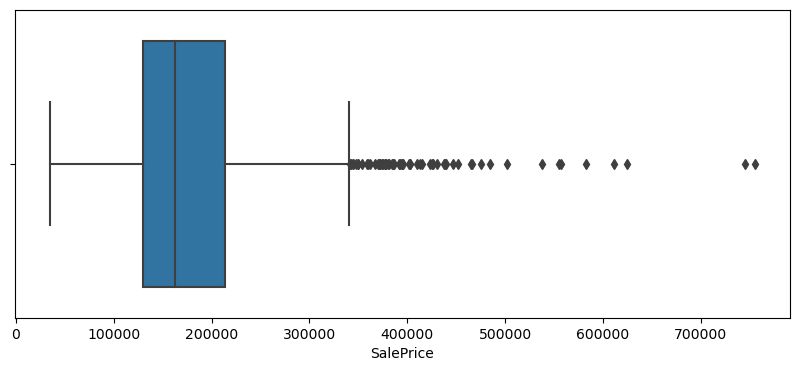

In [4]:
import seaborn as sns

plt.figure(figsize=(10, 4))
sns.boxplot(x=y)

In [5]:
train = train[train['SalePrice'] < 700000]

## Address Missing Data

In [6]:
#How many missing values are in each column
train.isnull().sum().sort_values(ascending=False).head(20)

PoolQC          1452
MiscFeature     1404
Alley           1367
Fence           1178
MasVnrType       871
FireplaceQu      690
LotFrontage      259
GarageYrBlt       81
GarageCond        81
GarageType        81
GarageFinish      81
GarageQual        81
BsmtFinType2      38
BsmtExposure      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Id                 0
dtype: int64

### Missing Value Columns and their descriptions

PoolQC: Pool quality (Excellent, Good)

MiscFeature: Miscellaneous feature not covered in other categories

Alley: Type of alley access to property

Fence: Fence quality

MasVnrType: Masonry veneer type

FireplaceQu: Fireplace quality

LotFrontage: Linear feet of street connected to property

GarageYrBlt: Year garage was built

GarageCond: Garage condition

GarageType: Garage Type

GarageFinish: Garage Finish

GarageQual: Garage Quality   

BsmtFinType2: Rating of basement finished area (if multiple types)

BsmtExposure: Basement Exposure

BsmtQual: Basement Quality

BsmtCond: Basement Condition

BsmtFinType1: Rating of basement finished area

MasVnrArea: Masonry veneer area in square feet

Electrical: Electrical system

### Tranform PoolQC to hasPool

#### Pool quality
Transform PoolQC to hasPool column because 99.5% of rows have value None for PoolQC.

PoolQC: Ex(Excellent), Gd(Good), TA(Average), Fa(Fair), NA -> hasPool: 0 or 1

In [7]:
def handle_pool_logic(df):
    df = df.copy()
    df['hasPool'] = df['PoolQC'].notnull().astype(int)
    df = df.drop(columns=['PoolQC'])
    return df

pool_transformer = FunctionTransformer(handle_pool_logic)

pipeline = Pipeline([
    ('pool_handler', pool_transformer),
])

### Impute Null Values in Categorical Columns with 'NA'

If columns: MiscFeature, Alley, Fence, FireplaceQu, GarageCond, GarageType, GarageFinish, GarageQual, BsmtFinType2, BsmtExposure, BsmtQual, BsmtCond, BsmtFinType1, Electrical, MasVnrType have any null values, replace them with "NA"


In [8]:
na_imputer = SimpleImputer(strategy='constant', fill_value='NA')

na_cat_columns = ["MiscFeature", "Alley", "Fence", "MasVnrType", "FireplaceQu", "GarageCond", "GarageType",
                  "GarageFinish", "GarageQual", "BsmtFinType2", "BsmtExposure", "BsmtQual", "BsmtCond", 
                  "BsmtFinType1", "Electrical"]

preprocessor = ColumnTransformer(transformers=[
    ('impute_na_categorical', na_imputer, na_cat_columns)
], remainder='passthrough')

pipeline = Pipeline([
    ('pool_handler', pool_transformer),
    ('fill_na', preprocessor)
])

#### How to test whole pipeline/parts of pipeline

##### Test one piece of the pipeline
transformed_sample = pipeline.named_steps['pool_handler'].transform(train.head())


##### Test whole pipeline
pipeline.set_output(transform="pandas")

transformed = pipeline.fit_transform(train)

##### Test every item in pipeline except that last (needed if the last item in pipeline is regressor)
transformed = pipeline[:-1].fit_transform(train)


### Impute null values in LotFrontage, GarageYrBlt with their median values


In [9]:
median_imputer = SimpleImputer(strategy = 'median')
median_columns = ["LotFrontage", "GarageYrBlt"]

#Consolidate previous and current ColumnTransformer into one.
preprocessor = ColumnTransformer(transformers=[
    ('impute_na_categorical', na_imputer, na_cat_columns),
    ('impute_median', median_imputer, median_columns),
], remainder='passthrough')

pipeline = Pipeline([
    ('pool_handler', pool_transformer),
    ('preprocessor', preprocessor)
])

### Impute null values in MasVnrArea column with 0

In [10]:
impute_0 = SimpleImputer(strategy = 'constant', fill_value = 0)

#Consolidate previous and current ColumnTransformer into one.
preprocessor = ColumnTransformer(transformers=[
    ('impute_na_categorical', na_imputer, na_cat_columns),
    ('impute_median', median_imputer, median_columns),
    ('impute_0', impute_0, ["MasVnrArea"])
], remainder='passthrough')

pipeline = Pipeline([
    ('pool_handler', pool_transformer),
    ('preprocessor', preprocessor)
])

### One hot encode the categorical columns and add linear regressor
### ColumnTransformer vs Pipeline in sklearn

Some categorical variable columns have null values that need to be imputed before One Hot Encoding(OHE) is performed on the column. It made sense to me at first to put both these steps into a ColumnTransformer. Step 1 would be the null imputation and Step 2 would be the OHE. However, ColumnTransformer is not the right tool to use here and instead Pipeline should be used instead. When using ColumnTransformer, each step works independently of each other with each step sending its individual output to the final dataframe. For example, if we put the column 'Street' through a ColumnTransformer with step 1 as null imputation and step 2 as OHE, then there would be one column in the output as Street_imputed (null values imputed and no OHE), and another column Street_ohe (yes OHE and no null imputation). The column Street_imputed created in Step 1 that only does null imputation and not OHE is not a model ready column because it still contains text instead of numerical values.

Instead we use Pipeline, which passes the output of step 1 into step 2. When using Pipeline, the output of step 1, null imputation, is passed into step 2, OHE. Once all the steps are complete, then the Pipeline sends its output to the final dataframe. When steps build on each other, Pipeline should be used instead of ColumnTransformer.

Put categorical columns that need both imputatation and OHE into cat_impute_ohe pipeline, while categorical columns that only need OHE do not need a seperate pipeline.

#### Linear Regressor

In [47]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer

categorical_cols = ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 
    'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 
    'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 
    'GarageQual', 'GarageCond', 'PavedDrive', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']

#categorical columns that only need OHE
cat_ohe_columns = list(set(categorical_cols) - set(na_cat_columns))

#For categorical columns where you need to impute missing values and do OHE
cat_impute_ohe_pipeline = Pipeline([
    ('impute_na_categorical', na_imputer),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

#Consolidate previous and current ColumnTransformer into one, add OHE.
preprocessor = ColumnTransformer(transformers=[
    ('cat_impute_ohe', cat_impute_ohe_pipeline, na_cat_columns), #for cat columns that need imputation and OHE
    ('cat_ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_ohe_columns), #cat columns that ony need OHE
    ('impute_median', median_imputer, median_columns),
    ('impute_0', impute_0, ["MasVnrArea"])
], remainder='passthrough')

#Add linear regressor
pipeline_linear = Pipeline([
    ('pool_handler', pool_transformer),
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])


### Add TranformerTargetRegressor to log transform the y variable

Apparently, its useful to log tranform the Y variable if it is skewed. The graph below shows that the Y variable, SalePrice is right skewed. Otherwise penalty for wrongly predicting the sale price of expensive houses is proportionally larger than the penalty for wrongly predicting sale prices for average or low cost houses. 

TransformerTargetRegressor wraps a sklearn pipeline and takes care of log transforming the Y variable before data is passed into the model and calls expm1 (exponential function) on the model's outputs to restore the predictions back to their original units.

<Axes: >

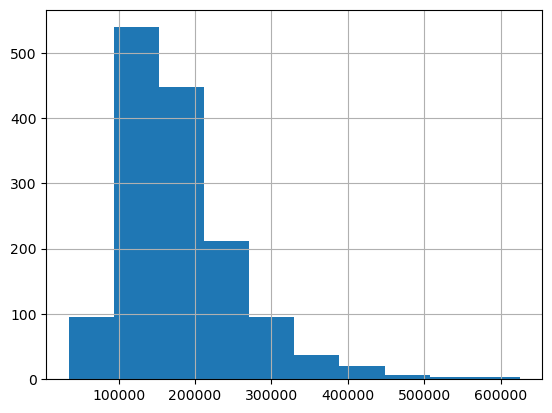

In [48]:
train['SalePrice'].hist()

#### Wrap the sklearn Pipeline in a TransformedTargetRegressor

In [49]:
model_linear = TransformedTargetRegressor(
    regressor=pipeline_linear,
    func=np.log1p,
    inverse_func=np.expm1
)

#### Baseline Cross Validation Scores for RMSE and MAPE(Mean Absolute Percentage Error)

In [50]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model_linear, X, y, cv=kf, scoring='neg_root_mean_squared_error')
mapes = cross_val_score(model_linear, X, y, cv=kf, scoring='neg_mean_absolute_percentage_error')
np.mean(scores) * -1, np.mean(mapes) * -1


(48607.37836391231, 0.09984402190395994)

**Baseline model w/ linear regressor: RMSE error is $48,607 and each prediction by the model is off by approximately 9.98%.**

#### Ridge Regressor

In [53]:
pipeline_ridge = Pipeline([
    ('pool_handler', pool_transformer),
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=1.0))
])

#for log transforming the y variable
model_ridge = TransformedTargetRegressor(
    regressor=pipeline_ridge,
    func=np.log1p,
    inverse_func=np.expm1
)

#hyperparameter tune
param_grid = {
    'regressor__model__alpha': [1.0] #[0.1, 1.0, 10.0, 100.0]
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=model_ridge,
    param_grid=param_grid, 
    cv=kf,
    scoring='neg_root_mean_squared_error'
)

grid_search.fit(X, y)

print("Ridge Regression Grid Search Results")
print(f"Best Parameters: {grid_search.best_params_}")

scores = cross_val_score(model_ridge, X, y, cv=kf, scoring='neg_root_mean_squared_error')
mapes = cross_val_score(model_ridge, X, y, cv=kf, scoring='neg_mean_absolute_percentage_error')
np.mean(scores) * -1, np.mean(mapes) * -1

Ridge Regression Grid Search Results
Best Parameters: {'regressor__model__alpha': 1.0}


(51165.44882185508, 0.10167011538231403)

**Ridge regressor model: RMSE error is $51,165 and each prediction by the model is off by approximately 10.17%.**

#### Lasso Regressor

In [60]:
pipeline_lasso = Pipeline([
    ('pool_handler', pool_transformer),
    ('preprocessor', preprocessor),
    ('model', Lasso(alpha=100))
])

#for log transforming the y variable
model_lasso = TransformedTargetRegressor(
    regressor=pipeline_lasso,
    func=np.log1p,
    inverse_func=np.expm1
)

#hyperparameter tune
param_grid = {
    'regressor__model__alpha': [100] #[0.1, 1.0, 10.0, 100.0, 1000]
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=model_lasso,
    param_grid=param_grid, 
    cv=kf,
    scoring='neg_root_mean_squared_error'
)

grid_search.fit(X, y)

print("Lasso Regression Grid Search Results")
print(f"Best Parameters: {grid_search.best_params_}")

scores = cross_val_score(model_lasso, X, y, cv=kf, scoring='neg_root_mean_squared_error')
mapes = cross_val_score(model_lasso, X, y, cv=kf, scoring='neg_mean_absolute_percentage_error')
np.mean(scores) * -1, np.mean(mapes) * -1

Lasso Regression Grid Search Results
Best Parameters: {'regressor__model__alpha': 100}


(77109.66490546809, 0.2794731717576874)

**Lasso regressor model: RMSE error is $77,110 and each prediction by the model is off by approximately 27.95%.**

#### XGBoost

In [59]:
xgb = XGBRegressor(
    n_estimators=500,   # Number of trees
    learning_rate=0.2,  # How much to "listen" to each tree
    max_depth=3,         # How complex each tree can be
    random_state=42
)

pipeline_xgb = Pipeline([
    ('pool_handler', pool_transformer),
    ('preprocessor', preprocessor),
    ('model', xgb)
])

model_xgb = TransformedTargetRegressor(
    regressor=pipeline_xgb,
    func=np.log1p,
    inverse_func=np.expm1
)

#hyperparameter tune
param_grid = {
    'regressor__model__n_estimators': [500], #[250, 500]      
    'regressor__model__learning_rate': [0.2],  #[0.1, 0.2, 0.4]
    'regressor__model__max_depth': [3], #[3]
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=model_xgb,
    param_grid=param_grid, 
    cv=kf,
    scoring='neg_root_mean_squared_error'
)

grid_search.fit(X, y)

print("XGBoost Regression Grid Search Results")
print(f"Best Parameters: {grid_search.best_params_}")

scores = cross_val_score(model_xgb, X, y, cv=kf, scoring='neg_root_mean_squared_error')
mapes = cross_val_score(model_xgb, X, y, cv=kf, scoring='neg_mean_absolute_percentage_error')
np.mean(scores) * -1, np.mean(mapes) * -1

XGBoost Regression Grid Search Results
Best Parameters: {'regressor__model__learning_rate': 0.2, 'regressor__model__max_depth': 3, 'regressor__model__n_estimators': 500}


(28305.46015625, 0.09091450273990631)

**XGBoost regressor model: RMSE error is $28,305 and each prediction by the model is off by approximately 9.09%.**

### Feature Engineering

#### How many years old is the house? - House Age

Assume this dataset goes up to the year 2010.

In [86]:
X['YearRemodAdd'].sort_values(ascending=False).head()

987    2010
898    2010
855    2010
378    2010
157    2010
Name: YearRemodAdd, dtype: int64

In [87]:
2010 - X['YearBuilt'].head()

0     7
1    34
2     9
3    95
4    10
Name: YearBuilt, dtype: int64

In [88]:
xgb = XGBRegressor(
    n_estimators=1000,   # Number of trees
    learning_rate=0.2,  # How much to "listen" to each tree
    max_depth=3,         # How complex each tree can be
    random_state=42
)

def house_age(df):
    df = df.copy()
    df['YearBuilt'] = 2010 - df['YearBuilt']
    return df

house_age_transformer = FunctionTransformer(house_age)

pipeline_age = Pipeline([
    ('house_age', house_age_transformer),
    ('pool_handler', pool_transformer),
    ('preprocessor', preprocessor),
    ('model', xgb)
])

model_age = TransformedTargetRegressor(
    regressor=pipeline_age,
    func=np.log1p,
    inverse_func=np.expm1
)

#hyperparameter tune
param_grid = {
    'regressor__model__n_estimators': [1000], #[250, 500, 1000]
    'regressor__model__learning_rate': [0.2],  #[0.1, 0.2, 0.4] 
    'regressor__model__max_depth': [3], #[1, 3, 5]
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=model_age,
    param_grid=param_grid, 
    cv=kf,
    scoring='neg_root_mean_squared_error'
)

grid_search.fit(X, y)

print("XGBoost w House Age Grid Search Results")
print(f"Best Parameters: {grid_search.best_params_}")

scores = cross_val_score(model_age, X, y, cv=kf, scoring='neg_root_mean_squared_error')
mapes = cross_val_score(model_age, X, y, cv=kf, scoring='neg_mean_absolute_percentage_error')
np.mean(scores) * -1, np.mean(mapes) * -1

XGBoost w House Age Grid Search Results
Best Parameters: {'regressor__model__learning_rate': 0.2, 'regressor__model__max_depth': 3, 'regressor__model__n_estimators': 1000}


(28128.45859375, 0.0913136750459671)

**XGBoost regressor model w House Age Feature Engineering: RMSE error is $28,128 and each prediction by the model is off by approximately 9.13%.**

### Total House sq ft  - Feature Engineering

Total House sq ft = TotalBsmtSF + 1stFlrSF + 2ndFlrSF + WoodDeckSF + OpenPorchSF + EnclosedPorch + 3SsnPorch + ScreenPorch +  PoolArea + GarageArea

In [89]:
xgb = XGBRegressor(
    n_estimators=500,   # Number of trees
    learning_rate=0.2,  # How much to "listen" to each tree
    max_depth=3,         # How complex each tree can be
    random_state=42
)

def sqft(df):
    df = df.copy()
    df['TotalSqFt'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF'] + \
        df['WoodDeckSF'] + df['OpenPorchSF'] + df['EnclosedPorch'] + df['3SsnPorch'] + \
        df['ScreenPorch'] + df['PoolArea'] + df['GarageArea']
    return df

sqft_transformer = FunctionTransformer(sqft)

pipeline_sqft = Pipeline([
    ('sqft', sqft_transformer),
    ('pool_handler', pool_transformer),
    ('preprocessor', preprocessor),
    ('model', xgb)
])

model_sqft = TransformedTargetRegressor(
    regressor=pipeline_sqft,
    func=np.log1p,
    inverse_func=np.expm1
)

#hyperparameter tune
param_grid = {
    'regressor__model__n_estimators': [500],  #[250, 500, 1000]   
    'regressor__model__learning_rate': [0.2],  #[0.1, 0.2, 0.4]
    'regressor__model__max_depth': [3], #[1, 3, 5]
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=model_sqft,
    param_grid=param_grid, 
    cv=kf,
    scoring='neg_root_mean_squared_error'
)

grid_search.fit(X, y)

print("XGBoost w/ Total SqFt Feature Grid Search Results")
print(f"Best Parameters: {grid_search.best_params_}")

scores = cross_val_score(model_sqft, X, y, cv=kf, scoring='neg_root_mean_squared_error')
mapes = cross_val_score(model_sqft, X, y, cv=kf, scoring='neg_mean_absolute_percentage_error')
np.mean(scores) * -1, np.mean(mapes) * -1

XGBoost w/ Total SqFt Feature Grid Search Results
Best Parameters: {'regressor__model__learning_rate': 0.2, 'regressor__model__max_depth': 3, 'regressor__model__n_estimators': 500}


(26374.125390625, 0.08734197467565537)

**XGBoost regressor model w Total Sqft Feature Engineering: RMSE error is $26,374 and each prediction by the model is off by approximately 8.73%.**

### Total_SqFt * Overall_Quality - Feature Engineering

In [90]:
xgb = XGBRegressor(
    n_estimators=500,   # Number of trees
    learning_rate=0.05,  # How much to "listen" to each tree
    max_depth=7,         # How complex each tree can be
    random_state=42
)

def sqft_times_quality(df):
    df = df.copy()
    df['sqft_times_quality'] = df['TotalSqFt'] * df['OverallQual']
    return df

sqft_transformer = FunctionTransformer(sqft)
sqft_times_quality_transformer = FunctionTransformer(sqft_times_quality)

pipeline_sqft_quality = Pipeline([
    ('sqft', sqft_transformer),
    ('sqft_times_quality', sqft_times_quality_transformer),
    ('pool_handler', pool_transformer),
    ('preprocessor', preprocessor),
    ('model', xgb)
])

model_sqft_quality = TransformedTargetRegressor(
    regressor=pipeline_sqft_quality,
    func=np.log1p,
    inverse_func=np.expm1
)

#hyperparameter tune
param_grid = {
    'regressor__model__n_estimators': [500],  #[500]
    'regressor__model__learning_rate': [0.05],    #[0.025, 0.05]
    'regressor__model__max_depth': [7], #[7, 9]
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=model_sqft_quality,
    param_grid=param_grid, 
    cv=kf,
    scoring='neg_root_mean_squared_error'
)

grid_search.fit(X, y)

print("XGBoost w/ Total SqFt * Overall Quality Grid Search Results")
print(f"Best Parameters: {grid_search.best_params_}")

scores = cross_val_score(model_sqft_quality, X, y, cv=kf, scoring='neg_root_mean_squared_error')
mapes = cross_val_score(model_sqft_quality, X, y, cv=kf, scoring='neg_mean_absolute_percentage_error')
np.mean(scores) * -1, np.mean(mapes) * -1

XGBoost w/ Total SqFt * Overall Quality Grid Search Results
Best Parameters: {'regressor__model__learning_rate': 0.05, 'regressor__model__max_depth': 7, 'regressor__model__n_estimators': 500}


(26156.473828125, 0.08939790576696396)

**XGBoost regressor model w Total Sqft * Quality Feature: RMSE error is $26,156 and each prediction by the model is off by approximately 8.94%.**

### Add target encoding/mean encoding to Neighborhood variable - Feature Engineering

In [91]:
xgb = XGBRegressor(
    n_estimators=2000,   # Number of trees
    learning_rate=0.025,  # How much to "listen" to each tree
    max_depth=3,         # How complex each tree can be
    random_state=42
)

target_encoding_cols = ['Neighborhood']

pipeline_neighborhood = Pipeline([
    ('target_encoder', TargetEncoder(cols=target_encoding_cols)),
    ('pool_handler', pool_transformer),
    ('preprocessor', preprocessor),
    ('regressor', xgb)
])

model_neighborhood = TransformedTargetRegressor(
    regressor=pipeline_neighborhood,
    func=np.log1p,
    inverse_func=np.expm1
)

#hyperparameter tune
param_grid = {
    'regressor__regressor__n_estimators': [2000],  #[250, 500, 1000, 1500, 2000]
    'regressor__regressor__learning_rate': [0.025],  #[0.0125, 0.025, 0.05, 0.1]
    'regressor__regressor__max_depth': [3], #[5, 7, 9]
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=model_neighborhood,
    param_grid=param_grid, 
    cv=kf,
    scoring='neg_root_mean_squared_error'
)

grid_search.fit(X, y)

print("XGBoost w/ Total SqFt * Overall Quality Grid Search Results")
print(f"Best Parameters: {grid_search.best_params_}")

scores = cross_val_score(model_neighborhood, X, y, cv=kf, scoring='neg_root_mean_squared_error')
mapes = cross_val_score(model_neighborhood, X, y, cv=kf, scoring='neg_mean_absolute_percentage_error')
np.mean(scores) * -1, np.mean(mapes) * -1

XGBoost w/ Total SqFt * Overall Quality Grid Search Results
Best Parameters: {'regressor__regressor__learning_rate': 0.025, 'regressor__regressor__max_depth': 3, 'regressor__regressor__n_estimators': 2000}


(28798.826171875, 0.08695825934410095)

**XGBoost regressor model w Neighborhood Target Encoding: RMSE error is $28,799 and each prediction by the model is off by approximately 8.70%.**

### Total Sqft * Neighborhood - Feature Engineering

In [92]:
xgb = XGBRegressor(
    n_estimators=500,   # Number of trees
    learning_rate=0.2,  # How much to "listen" to each tree
    max_depth=3,         # How complex each tree can be
    random_state=42
)

target_encoding_cols = ['Neighborhood']

def sqft_times_neighborhood(df):
    df = df.copy()
    df['sqft_times_neighborhood'] = df['TotalSqFt'] * df['Neighborhood']
    return df

sqft_transformer = FunctionTransformer(sqft)
sqft_times_quality_transformer = FunctionTransformer(sqft_times_quality)
sqft_times_neighborhood = FunctionTransformer(sqft_times_neighborhood)

pipeline_sqft_neighborhood = Pipeline([
    ('sqft', sqft_transformer),
    ('target_encoder', TargetEncoder(cols=target_encoding_cols)),
    ('sqft_times_neighborhood', sqft_times_neighborhood),
    ('pool_handler', pool_transformer),
    ('preprocessor', preprocessor),
    ('model', xgb)
])

model_sqft_neighborhood = TransformedTargetRegressor(
    regressor=pipeline_sqft_neighborhood,
    func=np.log1p,
    inverse_func=np.expm1
)

#hyperparameter tune
param_grid = {
    'regressor__model__n_estimators': [500], #[250, 500, 1000]   
    'regressor__model__learning_rate': [0.2], #[0.1, 0.2, 0.4]
    'regressor__model__max_depth': [3], #[1, 3, 5]
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=model_sqft_neighborhood,
    param_grid=param_grid, 
    cv=kf,
    scoring='neg_root_mean_squared_error'
)

grid_search.fit(X, y)

print("XGBoost w/ Total SqFt * Neighborhood Grid Search Results")
print(f"Best Parameters: {grid_search.best_params_}")

scores = cross_val_score(model_sqft_neighborhood, X, y, cv=kf, scoring='neg_root_mean_squared_error')
mapes = cross_val_score(model_sqft_neighborhood, X, y, cv=kf, scoring='neg_mean_absolute_percentage_error')
np.mean(scores) * -1, np.mean(mapes) * -1

XGBoost w/ Total SqFt * Neighborhood Grid Search Results
Best Parameters: {'regressor__model__learning_rate': 0.2, 'regressor__model__max_depth': 3, 'regressor__model__n_estimators': 500}


(28131.13046875, 0.08827874511480331)

**XGBoost regressor model w Total Sqft * Neighborhood Feature: RMSE error is $28,131 and each prediction by the model is off by approximately 8.83%.**

### Bedroom/Bathroom - Feature Engineering

In [94]:
xgb = XGBRegressor(
    n_estimators=1000,   # Number of trees
    learning_rate=0.1,  # How much to "listen" to each tree
    max_depth=3,         # How complex each tree can be
    random_state=42
)

def bedroom_divide_bathroom(df):
    df = df.copy()
    df['bedroom_divide_bathroom'] = df['BedroomAbvGr'] / (df['BsmtFullBath'] + df['BsmtHalfBath'] + df['FullBath'])
    return df

bedroom_divide_bathroom = FunctionTransformer(bedroom_divide_bathroom)

pipeline_bedroom_bathroom = Pipeline([
    ('sqft', sqft_transformer),
    ('bedroom_divide_bathroom', bedroom_divide_bathroom),
    ('pool_handler', pool_transformer),
    ('preprocessor', preprocessor),
    ('model', xgb)
])

model_bedroom_bathroom = TransformedTargetRegressor(
    regressor=pipeline_bedroom_bathroom,
    func=np.log1p,
    inverse_func=np.expm1
)

#hyperparameter tune
param_grid = {
    'regressor__model__n_estimators': [1000],  #[1000, 2000]     
    'regressor__model__learning_rate': [0.1],  #[0.05, 0.1]
    'regressor__model__max_depth': [3],  #[1, 3, 5]
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=model_bedroom_bathroom,
    param_grid=param_grid, 
    cv=kf,
    scoring='neg_root_mean_squared_error'
)

grid_search.fit(X, y)

print("XGBoost w/ Bedroom/Bathroom Grid Search Results")
print(f"Best Parameters: {grid_search.best_params_}")

scores = cross_val_score(model_bedroom_bathroom, X, y, cv=kf, scoring='neg_root_mean_squared_error')
mapes = cross_val_score(model_bedroom_bathroom, X, y, cv=kf, scoring='neg_mean_absolute_percentage_error')
np.mean(scores) * -1, np.mean(mapes) * -1

XGBoost w/ Bedroom/Bathroom Grid Search Results
Best Parameters: {'regressor__model__learning_rate': 0.1, 'regressor__model__max_depth': 3, 'regressor__model__n_estimators': 1000}


(26380.457421875, 0.0845018669962883)

**XGBoost regressor model w Bedroom/Bathroom Feature: RMSE error is $26,380 and each prediction by the model is off by approximately 8.45%.**

## Results

#### Table

In [95]:
results_data = [
    {"Model and Feature Engineering": "Linear Regression", "RMSE": 48607},
    {"Model and Feature Engineering": "Ridge Regression", "RMSE": 51165},
    {"Model and Feature Engineering": "Lasso Regression", "RMSE": 77110},
    {"Model and Feature Engineering": "XGBoost", "RMSE": 28305},
    {"Model and Feature Engineering": "XGBoost w/ House Age Feature", "RMSE": 28128},
    {"Model and Feature Engineering": "XGBoost w/ Total SqFt Feature", "RMSE": 26374},
    {"Model and Feature Engineering": "XGBoost w/ SqFt * House Quality", "RMSE": 26156},
    {"Model and Feature Engineering": "XGBoost w/ SqFt * Neighborhood Mean Encoding", "RMSE": 28131},
    {"Model and Feature Engineering": "XGBoost w/ SqFt * Bedroom/Bathroom", "RMSE": 26380}
]

results_df = pd.DataFrame(results_data)
results_df = results_df.sort_values(by='RMSE', ascending=True)

styled_table = results_df.style.set_caption("RMSE Results for Various Models + Feature Engineering over 5 Fold CV") \
                       .set_table_styles([{
                           'selector': 'caption',
                           'props': [
                               ('color', 'white'),
                               ('font-size', '16px'),
                               ('font-weight', 'bold'),
                               ('text-align', 'center'),
                               ('padding', '10px')
                           ]
                       }]) \
                       .format({"RMSE": "{:.2f}"})

styled_table

,Model and Feature Engineering,RMSE
6,XGBoost w/ SqFt * House Quality,26156.00
5,XGBoost w/ Total SqFt Feature,26374.00
8,XGBoost w/ SqFt * Bedroom/Bathroom,26380.00
4,XGBoost w/ House Age Feature,28128.00
7,XGBoost w/ SqFt * Neighborhood Mean Encoding,28131.00
3,XGBoost,28305.00
0,Linear Regression,48607.00
1,Ridge Regression,51165.00
2,Lasso Regression,77110.00


#### Bar Chart

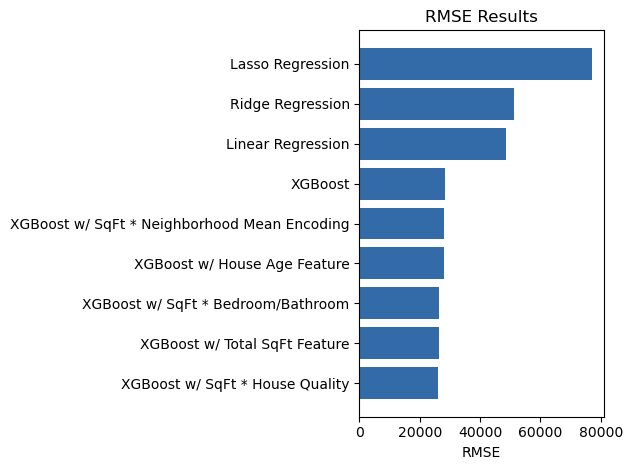

In [96]:
plt.barh(results_df['Model and Feature Engineering'], results_df['RMSE'], color='#326ba8')
plt.xlabel('RMSE')
plt.title('RMSE Results')
plt.tight_layout() 
plt.savefig('rmse_results_bar_chart.png')

### Best Model - Bedroom/Bathroom

In [73]:
xgb_model = XGBRegressor(
    n_estimators=1000,   # Number of trees
    learning_rate=0.1,  # How much to "listen" to each tree
    max_depth=3,         # How complex each tree can be
    random_state=42
)

def bedroom_divide_bathroom(df):
    df = df.copy()
    df['bedroom_divide_bathroom'] = df['BedroomAbvGr'] / (df['BsmtFullBath'] + df['BsmtHalfBath'] + df['FullBath'])
    #df['BsmtFullBath'] + df['BsmtHalfBath'] +
    return df

bedroom_divide_bathroom = FunctionTransformer(bedroom_divide_bathroom)

pipeline = Pipeline([
    ('sqft', sqft_transformer),
    ('sqft_times_quality', sqft_times_quality_transformer),
    ('bedroom_divide_bathroom', bedroom_divide_bathroom),
    ('pool_handler', pool_transformer),
    ('preprocessor', preprocessor),
    #('model', LinearRegression())
    ('model', xgb_model)
])

best_model = TransformedTargetRegressor(
    regressor=pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)


kf = KFold(n_splits=5, shuffle=True, random_state=42)
rmse_cross_val = cross_val_score(estimator=best_model, X=X, y=y, cv=kf, scoring='neg_root_mean_squared_error')
mape_cross_val = cross_val_score(estimator=best_model, X=X, y=y, cv=kf, scoring='neg_mean_absolute_percentage_error')
print('Cross Val RMSE: ', np.mean(rmse_cross_val) * -1)
print('Cross Val MAPE: ', np.mean(mape_cross_val) * -1)

Cross Val RMSE:  26093.51328125
Cross Val MAPE:  0.08654042184352875


### Discussion

#### #1. The house price predictions made by the best model is off by $23,259 or 8.46% on average.

See code block above with the header, "Best Model - Bedroom/Bathroom".

The average sale price of a house in this dataset was $180,141.

#### #2. XGBoost helped to reduce RMSE the most. More than feature engineering.

Changing the model from Linear Regressor to XGBoost Regressor reduced the RMSE from 48,607 to 26,336, a reduction of 45.81%. On the other hand, the best feature created during feature engineering only decreased the RMSE by 1%.

#### #3. Using sklearn Pipeline and TransformedTargetRegressor allowed this analysis to be much more readable by containerizing what would have been large blocks of code dedicated to data cleaning such as imputation.

With sklearn Pipeline, I could ensure the data preprocessing done to my training set is the exact same preprocessing that was done on my test set. I only had to write the pipeline once and then I could pass any data I wanted through the pipeline.

add a discussion point about the most impactful features when used linear regressor

#### #4. Which features were most important to the linear model?

#### Added standard scaler because im looking at coefficients of linear model to see which features were thought to have most impact on sale price.

In [30]:
categorical_cols = ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
    'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
       'BsmtFinType2', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', 
        'KitchenQual',
        'Functional', 'FireplaceQu', 'GarageType',
        'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'Fence',
       'MiscFeature', 'SaleType',
       'SaleCondition']

numerical_cols = X.select_dtypes(include=['number']).columns.tolist()

#categorical columns that only need OHE
cat_ohe_columns = list(set(categorical_cols) - set(na_cat_columns))

#For categorical columns where you need to impute missing values and do OHE
cat_impute_ohe_pipeline = Pipeline([
    ('impute_na_categorical', na_imputer),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

#without imputing medians standard scaler will be sending data to final df containing null values
numerical_pipeline = Pipeline([
    ('impute_median', median_imputer),
    ('standard_scaler', StandardScaler())
])

#Consolidate previous and current ColumnTransformer into one, add OHE.
preprocessor = ColumnTransformer(transformers=[
    ('cat_impute_ohe', cat_impute_ohe_pipeline, na_cat_columns), #for cat columns that need imputation and OHE
    ('cat_ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_ohe_columns), #cat columns that only need OHE
    ('numerical_pipeline', numerical_pipeline, numerical_cols),
    ('impute_0', impute_0, ["MasVnrArea"])
], remainder='passthrough')

#Add linear regressor
pipeline = Pipeline([
    ('pool_handler', pool_transformer),
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

model = TransformedTargetRegressor(
    regressor=pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

model.fit(X_train, y_train)
fitted_pipeline = model.regressor_
lr_step = fitted_pipeline.named_steps['regressor']
coefficients = lr_step.coef_
preprocessor_step = fitted_pipeline.named_steps['preprocessor']
feature_names = preprocessor_step.get_feature_names_out()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Weight': np.abs(coefficients)
}).sort_values(by='Weight', ascending=False)

indices_to_keep = []

for i in range(len(importance_df)):
    if 'ohe' not in importance_df.iloc[i]['Feature'] and 'remainder' not in importance_df.iloc[i]['Feature']:
        indices_to_keep.append(i)

numerical_importance_df = importance_df.iloc[indices_to_keep].copy()
numerical_importance_df = numerical_importance_df.sort_values(by = 'Weight', ascending = False)
numerical_importance_df.head()

,Feature,Weight
276,numerical_pipeline__GrLivArea,0.067223
264,numerical_pipeline__OverallQual,0.055137
266,numerical_pipeline__YearBuilt,0.050278
274,numerical_pipeline__2ndFlrSF,0.045224
293,numerical_pipeline__PoolArea,0.044783


The five most impactful numerical columns for predicting SalePrice were GrLivArea, OverallQual, YearBuilt, 2ndFlrSF, and PoolArea according to the Linear Regressor model.

### Kaggle Submission

In [31]:
best_model.fit(X, y)
test = pd.read_csv("test.csv")
predictions = best_model.predict(test)

In [32]:
submission = pd.DataFrame({
    'Id': test['Id'],
    'SalePrice': predictions
})
submission

,Id,SalePrice
0,1461,125234.382812
1,1462,160689.906250
2,1463,188316.656250
3,1464,198330.234375
4,1465,179072.656250
...,...,...
1454,2915,78029.078125
1455,2916,75812.273438
1456,2917,147426.609375
1457,2918,109548.382812


In [33]:
submission.to_csv('submission.csv', index=False)

try combining all 3 features that improved baseline xgboost model, redo best model cell

add xgb and gridsearch to Neighborhood mean encoding cell

short summary sentence after each cell

mape after every model. short explanation of results after each model. final thoughts. (what helped improve the most and what you want to work on in the future. why feature engineering didnt help much)

perhaps look at why if change random_state for train test split there is a huge difference in error. that means some data points contribute a lot of error

erased most of the explanations of the effects of the feature engineerings were. ex: neighborhood feature engineering didnt change rmse. so i should add those back at the bottom of each feature

Possible redudancy between "Fireplaces" and "FireplaceQu"

Possible redudancy between NA's of GarageCond, GarageType, GarageFinish, GarageQual

make the code run faster, takes maybe 5-10 minutes beacuse of the gridsearch